<a href="https://colab.research.google.com/github/Akash14-09/Machine_Learning/blob/main/Feature_Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [3]:
df = df.iloc[: , 2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
import seaborn as sns


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

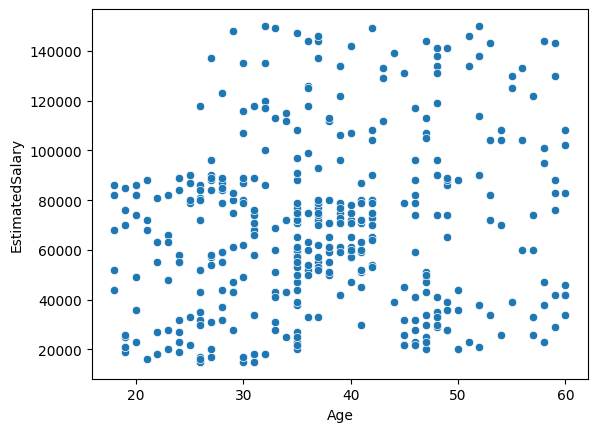

In [7]:
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1])

In [8]:
X = df.iloc[: , 0:2]
y= df.iloc[: , -1]

In [9]:
from sklearn.model_selection import train_test_split
X_train ,X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 2)

In [10]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [11]:
model = Sequential()
model.add(Dense(128 , activation = 'relu' , input_dim = 2))
model.add(Dense(1 , activation = 'sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer = 'Adam' , loss = 'binary_crossentropy' , metrics = ['accuracy'])

In [14]:
history = model.fit(X_train , y_train , epochs = 100 , validation_split = 0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4570 - loss: 831.5637 - val_accuracy: 0.7188 - val_loss: 736.6630
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6211 - loss: 524.7503 - val_accuracy: 0.2812 - val_loss: 222.7598
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4648 - loss: 175.2979 - val_accuracy: 0.7188 - val_loss: 168.4678
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4961 - loss: 98.5512 - val_accuracy: 0.7188 - val_loss: 41.9133
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5234 - loss: 43.3559 - val_accuracy: 0.7031 - val_loss: 4.3464
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5039 - loss: 35.5777 - val_accuracy: 0.7344 - val_loss: 6.6425
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5820 - loss: 35.2629 - val_accuracy: 0.2812 - val_loss: 110.0735
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5391 - loss: 48.9050 - val_accuracy: 0.28

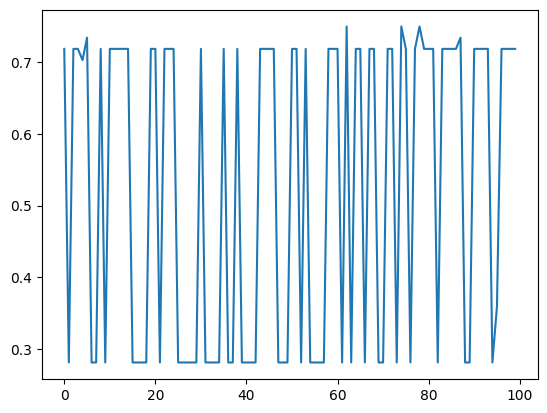

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])

##Applying Scaling

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<Axes: >

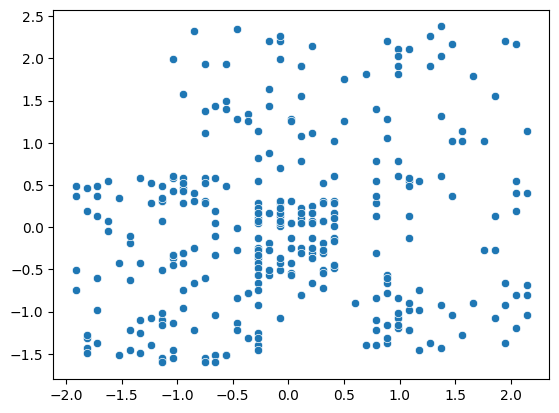

In [22]:
sns.scatterplot(x = X_train_scaled[: , 0] , y = X_train_scaled[: , 1])

In [23]:
model = Sequential()
model.add(Dense(128 , activation = 'relu' , input_dim = 2))
model.add(Dense(1 , activation = 'sigmoid'))

model.compile(optimizer = 'Adam' , loss= 'binary_crossentropy' , metrics = ['accuracy'])

history = model.fit(X_train_scaled , y_train , validation_data = (X_test_scaled , y_test) , epochs = 100)



Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6938 - loss: 0.6650 - val_accuracy: 0.8125 - val_loss: 0.6277
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7969 - loss: 0.6103 - val_accuracy: 0.7625 - val_loss: 0.5740
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8250 - loss: 0.5637 - val_accuracy: 0.7875 - val_loss: 0.5290
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8313 - loss: 0.5248 - val_accuracy: 0.7750 - val_loss: 0.4893
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8281 - loss: 0.4887 - val_accuracy: 0.7750 - val_loss: 0.4569
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8344 - loss: 0.4584 - val_accuracy: 0.7875 - val_loss: 0.4286
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8406 - loss: 0.4320 - val_accuracy: 0.7875 - val_loss: 0.4052
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8500 - loss: 0.4089 - val_accuracy: 0.8125 - val_l

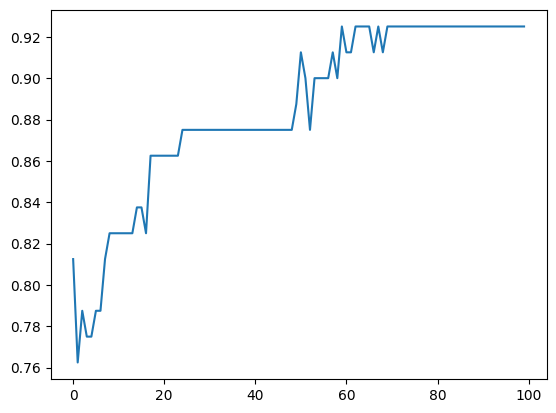

In [24]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])